# Step 2: Pretrain Autoencoder

AE pretraining (encoder + decoder) on the filtered ChEMBL corpus.

In [1]:
from molrl.dataloader import create_dataloader
from molrl.nnx_modules import SmilesEncoder, SmilesDecoder
from molrl.models import SmilesAutoencoder
from molrl.training import autoencoder_train_step, autoencoder_val_step
from molrl.eval import smiles_validity, levenshtein_distance
from molrl.tokenizer import encoding_to_smiles
from flax import nnx
from jax import numpy as jnp
import numpy as np
import optax
import orbax.checkpoint as ocp
from pathlib import Path
import random
import pandas as pd
from jax import vmap
from molrl.cheminformatics import calculate_ecfps, tanimoto_one_to_many

/Users/derekvantilborg/Dropbox/coding/OOD-proof-mol-RL/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
hypers = {
    "dataset": "chembl",
    "batch_size": 256,
    "max_num_updates": 200_000,
    "n_eval_batches": 32,
    "eval_every": 2500,
    "early_stop_patience_evals": 5,
    "learning_rate": 3e-4,
    "warmup_steps": 500,
    "model_save_path": "checkpoints/pretrained_autoencoder",
    "vocab_size": 36,
    "max_seq_len": 102,
    "latent_dim": 128,
    "encoder_emb_dim": 64,
    "encoder_conv_channels": (128, 256, 512),
    "encoder_kernel_sizes": (9, 9, 11),
    "encoder_dropout_rate": 0.2,
    "decoder_hidden_dim": 512,
    "decoder_emb_dim": 64,
}

In [3]:
# init the dataloaders
train_loader = create_dataloader("../step_1_data_preparation/chembl_train_aug.h5",
                                 batch_size=hypers["batch_size"],
                                 shuffle=True,
                                 to_device=True)

val_loader = create_dataloader("../step_1_data_preparation/chembl_val_aug.h5",
                               batch_size=hypers["batch_size"],
                               shuffle=True,
                               to_device=True)

# init the model
encoder = SmilesEncoder(vocab_size=hypers["vocab_size"],
                        latent_dim=hypers["latent_dim"],
                        emb_dim=hypers["encoder_emb_dim"],
                        conv_channels=hypers["encoder_conv_channels"],
                        kernel_sizes=hypers["encoder_kernel_sizes"],
                        dropout_rate=hypers["encoder_dropout_rate"])

decoder = SmilesDecoder(vocab_size=hypers["vocab_size"],
                        max_seq_len=hypers["max_seq_len"],
                        latent_dim=hypers["latent_dim"],
                        hidden_dim=hypers["decoder_hidden_dim"],
                        emb_dim=hypers["decoder_emb_dim"])

model = SmilesAutoencoder(encoder, decoder)

# init the optimizer with linear warmup + cosine decay
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=hypers["learning_rate"],
    warmup_steps=hypers["warmup_steps"],
    decay_steps=hypers["max_num_updates"],
    end_value=hypers["learning_rate"] * 0.1,
)
optimizer = nnx.Optimizer(model, optax.adamw(learning_rate=schedule), wrt=nnx.Param)

In [9]:
n_updates = 0
train_losses = []
best_val_loss = float("inf")
no_improve_evals = 0
stop_training = False

ckpt_dir = (Path.cwd() / hypers["model_save_path"]).resolve()
ckpt_dir.parent.mkdir(parents=True, exist_ok=True)
checkpointer = ocp.PyTreeCheckpointer()

while n_updates < hypers["max_num_updates"] and not stop_training:
    for batch in train_loader:
        loss = autoencoder_train_step(model, optimizer, batch, pad_token_id=0)
        train_losses.append(float(loss))
        n_updates += 1

        if n_updates % hypers["eval_every"] == 0:
            print(f"Evaluating at step {n_updates}...")
            current_train_loss = sum(train_losses) / len(train_losses)
            train_losses = []
            val_losses = []
            reconstructed_smiles = []
            smiles_pairs = []  # (input, reconstructed) pairs for edit distance

            for i, val_batch in enumerate(val_loader):
                if i < hypers["n_eval_batches"]:
                    val_losses.append(float(autoencoder_val_step(model, val_batch, pad_token_id=0)))

                    # reconstruct: encode → decode → argmax → SMILES
                    input_ids = jnp.asarray(val_batch if not isinstance(val_batch, dict) else val_batch["sequences"], dtype=jnp.int32)
                    logits, _ = model(input_ids, input_ids, is_training=False)
                    pred_tokens = jnp.argmax(logits, axis=-1)  # [batch, seq_len]
                    for j in range(pred_tokens.shape[0]):
                        input_smi = encoding_to_smiles(input_ids[j].tolist())
                        recon_smi = encoding_to_smiles(pred_tokens[j].tolist())
                        if recon_smi is not None:
                            reconstructed_smiles.append(recon_smi)
                        if input_smi is not None and recon_smi is not None:
                            smiles_pairs.append((input_smi, recon_smi))
                else:
                    break
            val_loss = sum(val_losses) / len(val_losses)
            validity = smiles_validity(reconstructed_smiles) if reconstructed_smiles else 0.0
            avg_edit_dist = np.mean([levenshtein_distance(a, b) for a, b in smiles_pairs]) if smiles_pairs else float("nan")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                no_improve_evals = 0
                checkpointer.save(str(ckpt_dir), nnx.state(model), force=True)
                print(f"New best val loss: {best_val_loss:.4f}. Saved checkpoint to {ckpt_dir}")
            else:
                no_improve_evals += 1
                print(f"No val improvement for {no_improve_evals}/{hypers['early_stop_patience_evals']} eval checks")

            print(f"Step {n_updates}, Train loss: {current_train_loss:.4f}, Val loss: {val_loss:.4f}, Recon validity: {validity:.4f}, Avg edit dist: {avg_edit_dist:.2f}")

            # print a random reconstruction example
            if smiles_pairs:
                inp, rec = random.choice(smiles_pairs)
                print(f"  Example:  IN: {inp}")
                print(f"           OUT: {rec}")

            if no_improve_evals >= hypers["early_stop_patience_evals"]:
                print("Early stopping triggered.")
                stop_training = True
                break

        if n_updates >= hypers["max_num_updates"]:
            break

if best_val_loss == float("inf"):
    checkpointer.save(str(ckpt_dir), nnx.state(model), force=True)
    print(f"Training ended before eval. Saved fallback checkpoint to {ckpt_dir}")
else:
    print(f"Training finished. Best val loss: {best_val_loss:.4f}")

Evaluating at step 102500...
New best val loss: 0.0469. Saved checkpoint to /Users/derekvantilborg/Dropbox/coding/OOD-proof-mol-RL/project/step_3_pretrain_autoencoder/checkpoints/pretrained_autoencoder
Step 102500, Train loss: 0.0841, Val loss: 0.0469, Recon validity: 0.6893, Avg edit dist: 1.12
  Example:  IN: c1c(-c2nnsc2)ccc(c1)NC(=O)N1CC(CC1)O
           OUT: c1c(-c2nnsc2)ccc(c1)NC(=O)N1CC(CC1)O
Evaluating at step 105000...
No val improvement for 1/5 eval checks
Step 105000, Train loss: 0.0837, Val loss: 0.0505, Recon validity: 0.6812, Avg edit dist: 1.23
  Example:  IN: O=C(C)OC12C(C(C)C=CC(C)(C)C(=O)CCC(=C)C(C2C(C(C1)C)OC(=O)c1ccccc1)OC(=O)C)=O
           OUT: O=C(C)OC12C(C(C)C=CC(C)(C)C(CO)C(C(CC(C(C(C(C1C1)O)OC(=O)c1ccccc1)OC(=O)C)=O
Evaluating at step 107500...
No val improvement for 2/5 eval checks
Step 107500, Train loss: 0.0835, Val loss: 0.0473, Recon validity: 0.6959, Avg edit dist: 1.14
  Example:  IN: O1CC(CC1)S(=O)(c1cc(-c2cnc(N)cc2C(F)(F)F)cc(c1)N1CCOCC1)=O
          

In [4]:
# Load the checkpoint into a fresh model instance.
ckpt_dir = (Path.cwd() / hypers["model_save_path"]).resolve()
if not ckpt_dir.exists():
    raise FileNotFoundError(f"Checkpoint not found at {ckpt_dir}. Run the training loop cell first.")

checkpointer = ocp.PyTreeCheckpointer()

encoder = SmilesEncoder(vocab_size=hypers["vocab_size"],
                        latent_dim=hypers["latent_dim"],
                        emb_dim=hypers["encoder_emb_dim"],
                        conv_channels=hypers["encoder_conv_channels"],
                        kernel_sizes=hypers["encoder_kernel_sizes"],
                        dropout_rate=hypers["encoder_dropout_rate"])

decoder = SmilesDecoder(vocab_size=hypers["vocab_size"],
                        max_seq_len=hypers["max_seq_len"],
                        latent_dim=hypers["latent_dim"],
                        hidden_dim=hypers["decoder_hidden_dim"],
                        emb_dim=hypers["decoder_emb_dim"])

model = SmilesAutoencoder(encoder, decoder)

# Restore using a template state so list/dict key types match NNX internals.
restored_state = checkpointer.restore(str(ckpt_dir), item=nnx.state(model))
nnx.update(model, restored_state)

# Quick sanity check: restored model should run on a validation batch.
test_batch = next(iter(val_loader))
restored_val_loss = float(autoencoder_val_step(model, test_batch, pad_token_id=0))
print(f"Restored model validation loss: {restored_val_loss:.4f}")


/Users/derekvantilborg/Dropbox/coding/OOD-proof-mol-RL/.venv/lib/python3.13/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:712: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Restored model validation loss: 0.0457


In [15]:
import pandas as pd
import jax
from jax import vmap
from molrl.training import autoencoder_reconstruction_loss_per_item
from molrl.cheminformatics import calculate_ecfps, tanimoto_one_to_many
from molrl.tokenizer import encode_smiles_list
from rdkit.Chem import MolFromSmiles
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.warning")
RDLogger.DisableLog("rdApp.error")

# --- AE inference on the non-augmented test set ---
test_df = pd.read_csv("../step_1_data_preparation/chembl_test.csv")
test_encodings, test_smiles, _ = encode_smiles_list(test_df["standardized_smiles"].tolist())
print(f"Encoded {len(test_smiles)}/{len(test_df)} test molecules")

all_losses, all_validity, all_edit_dist = [], [], []
bs = hypers["batch_size"]
for start in range(0, len(test_encodings), bs):
    batch = jnp.asarray(test_encodings[start:start+bs], dtype=jnp.int32)

    # per-item NLL
    losses = autoencoder_reconstruction_loss_per_item(model, batch, pad_token_id=0, is_training=False)
    all_losses.extend(losses.tolist())

    # reconstruction → validity + edit distance
    logits, _ = model(batch, batch, is_training=False)
    pred_tokens = jnp.argmax(logits, axis=-1)
    for j in range(pred_tokens.shape[0]):
        rec_smi = encoding_to_smiles(pred_tokens[j].tolist())
        inp_smi = test_smiles[start + j]
        all_validity.append(1 if rec_smi and MolFromSmiles(rec_smi) else 0)
        all_edit_dist.append(levenshtein_distance(inp_smi, rec_smi) if rec_smi else float("nan"))

    if start % (bs * 100) == 0:
        print(f"  {start + len(batch)}/{len(test_encodings)}...")

unfamiliarity_scores = np.log(np.array(all_losses))
validity = np.array(all_validity)
edit_distance = np.array(all_edit_dist, dtype=np.float32)

print(f"\nMean unfamiliarity: {np.mean(unfamiliarity_scores):.4f}")
print(f"Mean validity:      {np.mean(validity):.4f}")
print(f"Mean edit distance: {np.nanmean(edit_distance):.2f}")

test_results = pd.DataFrame({
    "smiles": test_smiles,
    "unfamiliarity": unfamiliarity_scores,
    "validity": validity,
    "edit_distance": edit_distance
})

print(f"\nResults: {test_results.shape}")
test_results.describe()

Encoded 125214/125214 test molecules
  256/125214...
  25856/125214...
  51456/125214...
  77056/125214...
  102656/125214...

Mean unfamiliarity: -5.0086
Mean validity:      0.7273
Mean edit distance: 0.97

Results: (125214, 4)


,unfamiliarity,validity,edit_distance
count,125214.000000,125214.000000,125214.000000
mean,-5.008584,0.727347,0.970682
std,2.314482,0.445326,2.384578
min,-12.400119,0.000000,0.000000
25%,-6.835054,0.000000,0.000000
50%,-4.877379,1.000000,0.000000
75%,-3.050779,1.000000,1.000000
max,1.371710,1.000000,95.000000


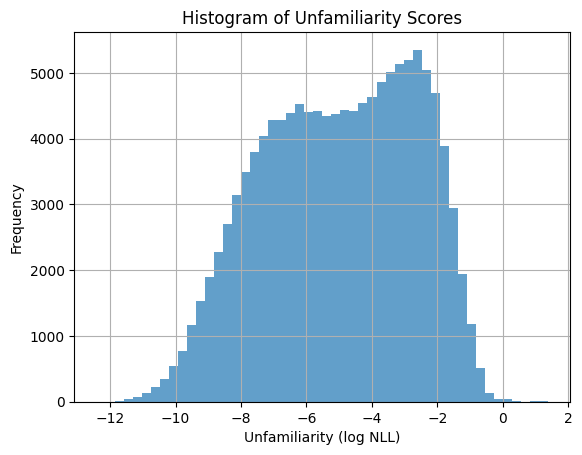

In [16]:
# historgam of unfamiliarity scores
import matplotlib.pyplot as plt
plt.hist(unfamiliarity_scores, bins=50, alpha=0.7)
plt.title("Histogram of Unfamiliarity Scores")
plt.xlabel("Unfamiliarity (log NLL)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()  